Importing drawing library

In [435]:
import matplotlib
import matplotlib.pyplot as plt

Importing utility

In [436]:
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence

Qiskit circuit definition

In [437]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz

Qiskit Backend

In [438]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

Qiskit hight performance simulation

In [439]:
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager

Manipulate QUBO problem

In [440]:
import qubovert

Load QUBO problem

In [441]:
data = np.load('sat.npz')
qubo_mat = data['qubo']
n_qubits = len(data['syms'])
print(data['syms'])

['circ_sat.$id00005.A' 'circ_sat.$id00005.B' 'circ_sat.$id00005.Y'
 'circ_sat.$id00006.A' 'circ_sat.$id00006.B' 'circ_sat.$id00006.Y'
 'circ_sat.$id00004.A' 'circ_sat.$id00004.Y' 'circ_sat.b' 'circ_sat.a'
 'circ_sat.c']


From the output above we understand we are interested in qubits 8, 9, 10 that are respectevely the variables b, a and c in our logic formula ($a \land (\neg (b \lor c)).$).

Convert from QUBO to Ising form

In [442]:
qubo = qubovert.utils.matrix_to_qubo(qubo_mat)
ising = qubovert.utils.qubo_to_quso(qubo)
qubo_dict = dict(qubo)
ising_dict = dict(ising)
ising_dict.pop(())
ising_mat = qubovert.utils.qubo_to_matrix(ising_dict)

The next block of code verifies that the solutions obtained from the different version of our problem are equivalent

In [443]:
qubo_solution = qubo.solve_bruteforce()
ising_original_solution = ising.solve_bruteforce()
ising_solution = qubovert.QUSO(ising_dict).solve_bruteforce()

print('a\tb\tc')
print(qubo_solution.get(9), qubo_solution.get(8), qubo_solution.get(10), 'QUBO', sep='\t')
print(ising_original_solution.get(9), ising_original_solution.get(8), ising_original_solution.get(10), 'ISING', sep='\t')
print(ising_solution.get(9), ising_solution.get(8), ising_solution.get(10), 'Ising no offset', sep='\t')


a	b	c
1	0	0	QUBO
-1	1	1	ISING
-1	1	1	Ising no offset


Building pauli operators to represent cost matrix

In [444]:
def build_paulis(matrix):
    pauli_list = []
    for i in range(len(matrix)):
        pauli_list.append(('Z', [i], matrix[i][i]))
        for j in range(i+1, len(matrix)):
            pauli_list.append(('ZZ', [i, j], matrix[i][j]))
    return pauli_list
 
 
sat_paulis = build_paulis(ising_mat)
cost_hamiltonian = SparsePauliOp.from_sparse_list(sat_paulis, n_qubits)

Building QAOA circuit with 10 levels

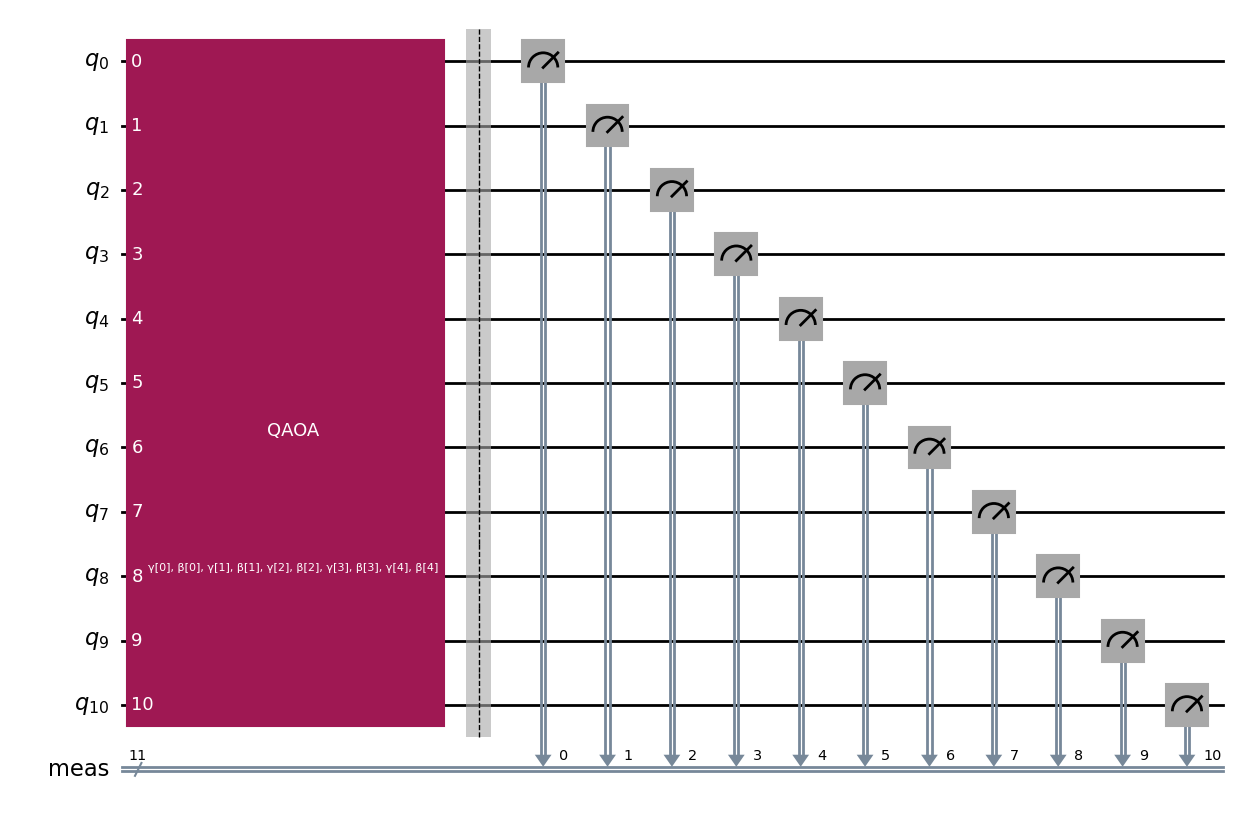

In [445]:
ansatz = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=5)
ansatz.measure_all()
ansatz.draw('mpl')

Transpile the ciurcuit

In [446]:
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

candidate_circuit = pm.run(ansatz)

Estimate cost 

In [447]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)
 
    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])
 
    results = job.result()[0]
    cost = results.data.evs
  
    return cost

Run experiment:
- optimize parameters
- run optimized ciurcuit
- retreive results

In [448]:
def run_experimet(): 
    init_params = np.random.rand(ansatz.num_parameters) * 2 * np.pi

    with Session(backend=backend) as session:
        estimator = Estimator(mode=session)
        estimator.options.default_shots = 1000

    
        result = minimize(
            cost_func_estimator,
            init_params,
            args=(candidate_circuit, cost_hamiltonian, estimator),
            method='COBYLA',
            tol=1e-10,
        )
    optimized_circuit = candidate_circuit.assign_parameters(result.x)

    sampler = Sampler(mode=backend)
    sampler.options.default_shots = 10000
    
    pub = (optimized_circuit,)
    job = sampler.run([pub], shots=int(1e4))
    counts_int = job.result()[0].data.meas.get_int_counts()
    counts_bin = job.result()[0].data.meas.get_counts()
    shots = sum(counts_int.values())
    final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
    
    first_3 = {}
    for (key, value) in final_distribution_bin.items():
        first = key[:3]
        if first in first_3.keys():
            first_3[first] += value
        else:
            first_3[first] = value

    lst = list(first_3.items())
    lst.sort()
    return lst

define how to plot results

In [449]:
row = 4
column = 4

run experiments

In [450]:
results = []
for i in range (row*column):
    res = run_experimet()
    print(res)
    results.append(res)

[('000', 0.12670000000000006), ('001', 0.12710000000000005), ('010', 0.1468999999999998), ('011', 0.1552999999999997), ('100', 0.10290000000000019), ('101', 0.09890000000000024), ('110', 0.12010000000000019), ('111', 0.12210000000000028)]
[('000', 0.12839999999999985), ('001', 0.1264999999999999), ('010', 0.1290999999999999), ('011', 0.12440000000000018), ('100', 0.11930000000000016), ('101', 0.12040000000000015), ('110', 0.1259), ('111', 0.12600000000000003)]
[('000', 0.1292999999999999), ('001', 0.1355999999999998), ('010', 0.13359999999999972), ('011', 0.12730000000000005), ('100', 0.1281), ('101', 0.12290000000000019), ('110', 0.11270000000000018), ('111', 0.11050000000000014)]
[('000', 0.11840000000000013), ('001', 0.13149999999999978), ('010', 0.08370000000000015), ('011', 0.07320000000000011), ('100', 0.16779999999999984), ('101', 0.19639999999999957), ('110', 0.12240000000000013), ('111', 0.10660000000000018)]
[('000', 0.10980000000000016), ('001', 0.11470000000000014), ('010',

Save experiments'results

In [451]:
with open('raw_data.tsv', 'w') as out:
    for val in results[0]:
        out.write(val[0] + '\t')
    out.write('\n')
    for r in results:
        for val in r:
            out.write(str(val[1]) + '\t')
        out.write('\n')

Function to plot results (in red the correct result, in purple the most frequent result, with light green background the experiments that retreive the correct assignement, in lignt red the other)

In [452]:
def plot_experiments(
    experiments,
    titles=None,
    highlight_keys=None,
    nrows=1,
    ncols=None,
    max_color="mediumpurple",
    other_color="lightgrey",
    highlight_color="red",
    figsize=20
):
    if highlight_keys is None:
        highlight_keys = []

    n_exp = len(experiments)

    if ncols is None:
        ncols = int(np.ceil(n_exp / nrows))

    fig, axes = plt.subplots(nrows, ncols, figsize=(10,7))
    axes = np.array(axes).reshape(-1)

    for i, exp in enumerate(experiments):
        ax = axes[i]

        keys = [k for k, _ in exp]
        freqs = [f for _, f in exp]

        max_idx = np.argmax(freqs)

        max_key = keys[max_idx]

        if max_key in highlight_keys:
            ax.set_facecolor("#a2ffa2")   # light green
        else:
            ax.set_facecolor("#ffb7b7")   # light red

        colors = [other_color] * len(freqs)
        colors[np.argmax(freqs)] = max_color

        ax.bar(keys, freqs, color=colors)

        if titles:
            ax.set_title(titles[i])

        # Rotate labels if necessary
        ax.tick_params(axis='x', rotation=45)

        # Highlight keys
        for tick in ax.get_xticklabels():
                if tick.get_text() in highlight_keys:
                    tick.set_color(highlight_color)
                    tick.set_fontweight("bold")

    # Remove unused axes
    for ax in axes[n_exp:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

Plot the result

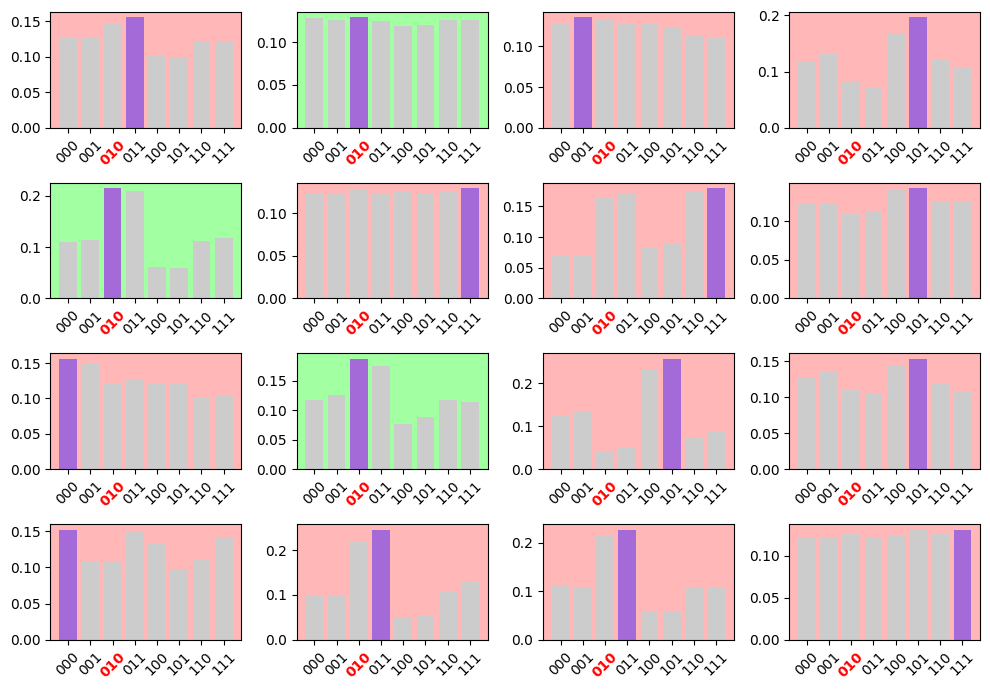

In [453]:
plot_experiments(
    results,
    titles="",
    highlight_keys=["010"],
    nrows=row,
    ncols=column,
    max_color="#A46AD8",
    other_color="#CCCCCC",
)